In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('toyota_unclean.csv')

Data Understanding

In [7]:
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016.0,16000.0,Manual,24089.0,Petrol,265.0,36.2,2.0
1,GT86,2017.0,15995.0,Manual,18615.0,Petrol,145.0,36.2,2.0
2,GT86,2015.0,13998.0,Manual,27469.0,Petrol,265.0,36.2,2.0
3,GT86,2017.0,NaN,Manual,14736.0,Petrol,150.0,36.2,2.0
4,GT86,2017.0,NaN,Manual,36284.0,Petrol,145.0,36.2,2.0


Data Cleaning

In [8]:
df.isnull().sum()

model            0
year            41
price           26
transmission     0
mileage         19
fuelType         0
tax             11
mpg              5
engineSize       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(39)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['year'] = df['year'].fillna(df['year'].median())

In [16]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

EDA

In [17]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6614.000000,6614.000000,6614.000000,6614.000000,6614.000000,6614.000000
mean,2016.731327,12447.148473,22991.282885,94.089809,63.189537,1.469277
std,2.205720,6207.286132,19139.224142,73.767273,15.800512,0.431389
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8276.750000,9599.250000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18634.500000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31138.250000,145.000000,70.600000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.200000


<Axes: xlabel='price', ylabel='Count'>

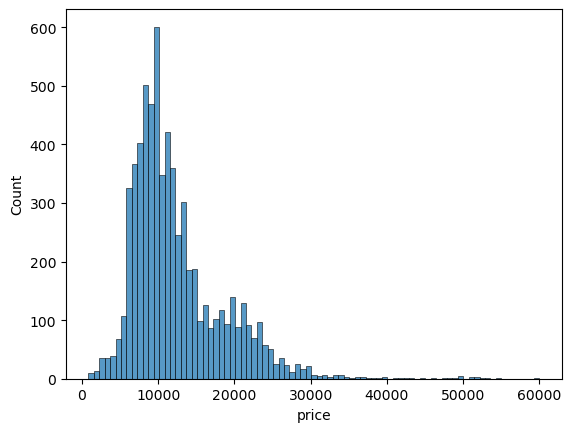

In [18]:
sns.histplot(df['price'])

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'mileage'}>,
        <Axes: title={'center': 'tax'}>],
       [<Axes: title={'center': 'mpg'}>,
        <Axes: title={'center': 'engineSize'}>]], dtype=object)

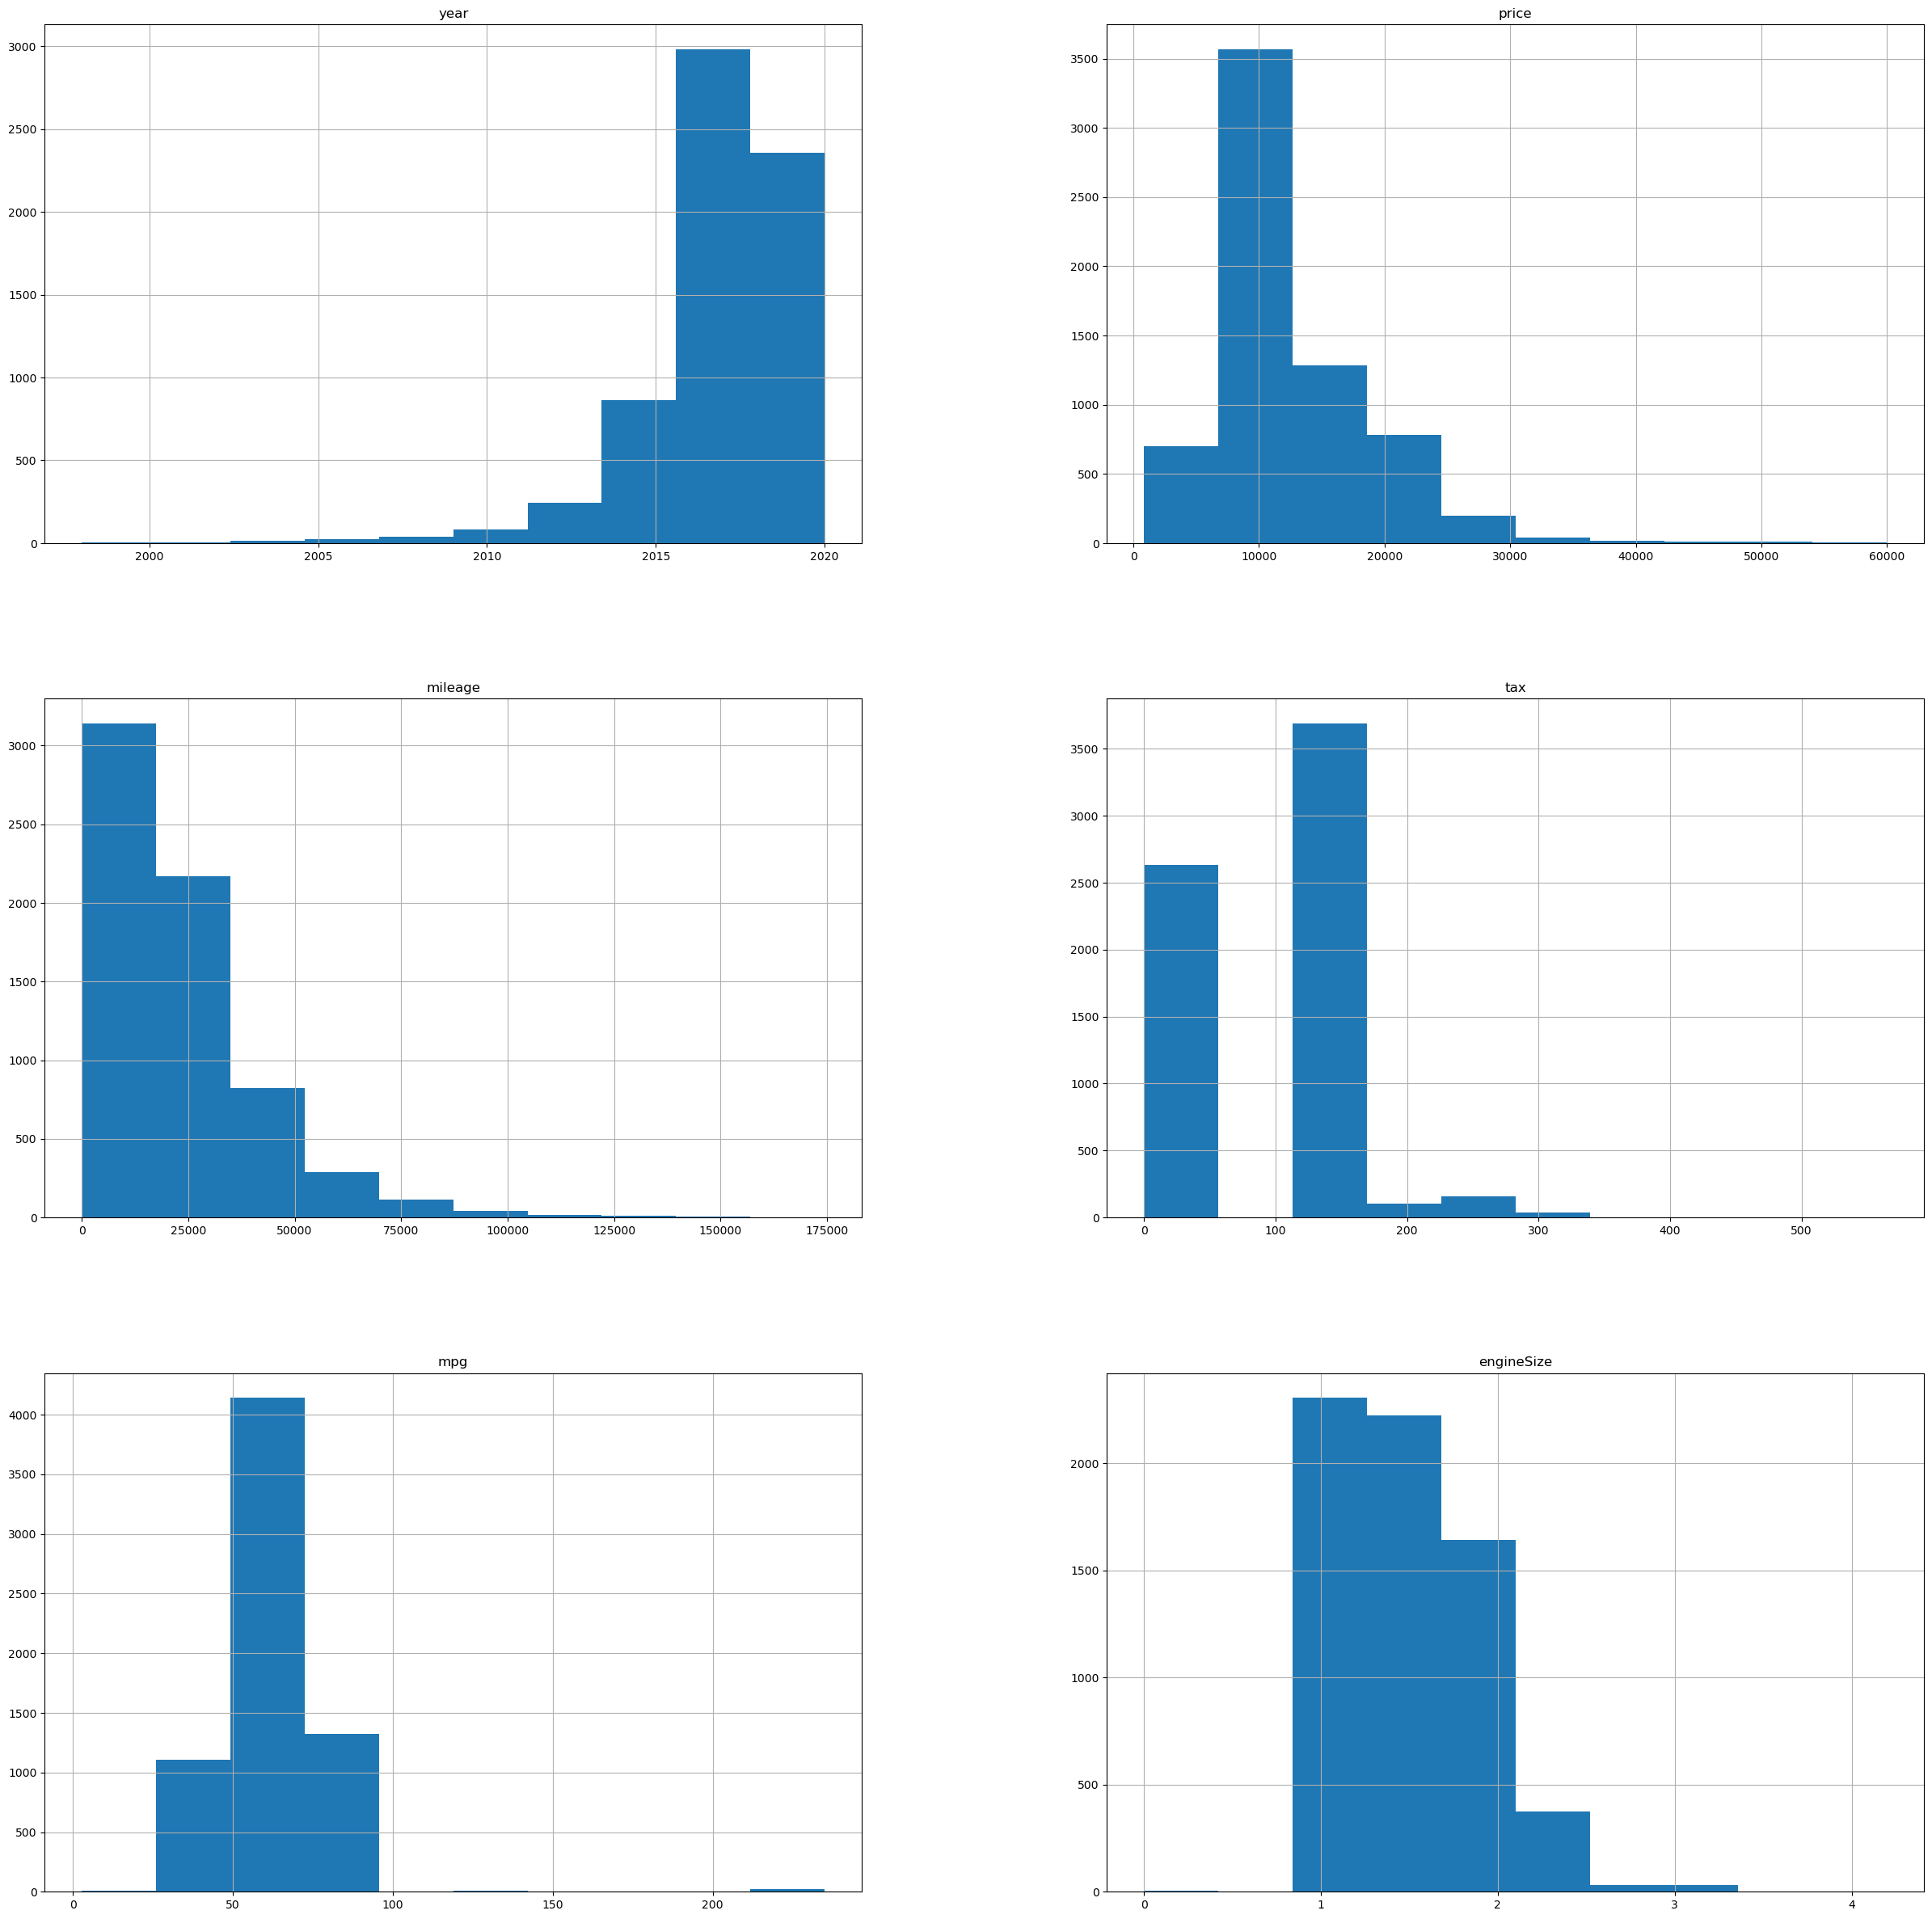

In [19]:
df.hist(figsize = (30, 30))

<Axes: xlabel='year', ylabel='price'>

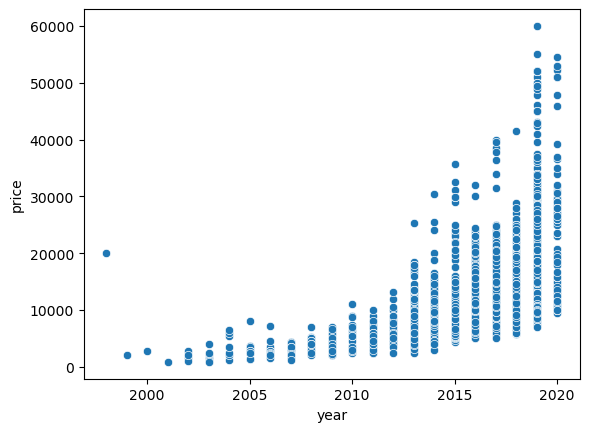

In [20]:
sns.scatterplot(x='year', y='price', data=df)

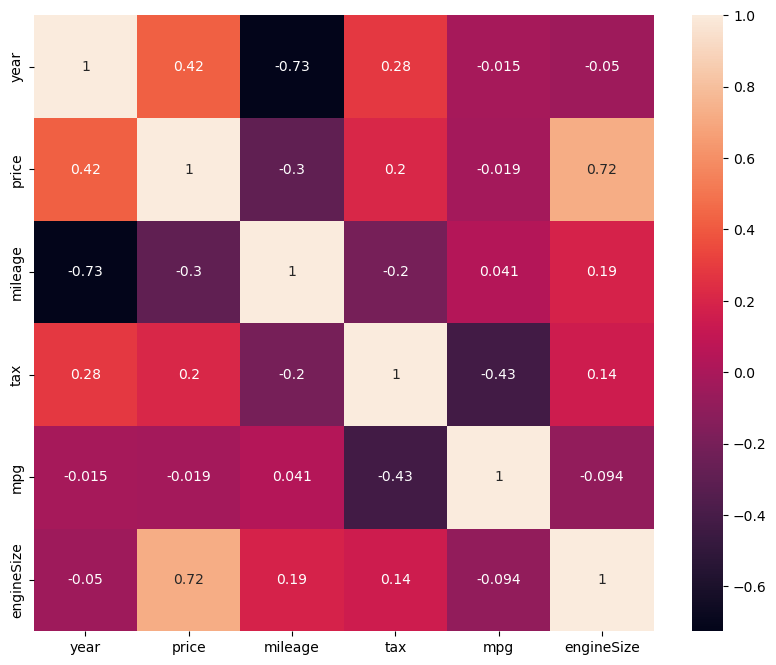

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True);

In [23]:
df = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'], drop_first=True)

In [24]:
X = df.drop('price', axis=1)
y = df['price']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R-squared: 0.9231415537860816


In [51]:
input_data = {
    'model' : 'GT86',   
    'year' : 2019,
    'transmission' : 'Manual',
    'mileage' : 24089,
    'fuelType' : 'Petrol',
    'tax' : 265,
    'mpg' : 36.2,
    'engineSize' : 2
}
input_df = pd.DataFrame([input_data])

In [52]:
input_encoded = pd.get_dummies(input_df)

In [53]:
input_encoded = input_encoded.reindex(columns=X_train.columns, fill_value=0)

In [54]:
predicted_price = model.predict(input_encoded)[0]
print(predicted_price)

14027.568627852714


In [55]:
print(r2_score(y_test, y_pred))

0.9231415537860816
